# ViT (Vision Transformer) Training
Uses `keras_hub` — the official Keras team library (Keras 3-native), with a pretrained `ViTBackbone` preset. No HuggingFace transformers, no old-Python-only packages like tfimm. Follows the same Phase 1 (frozen) -> Phase 2 (fine-tune) pattern used for the other models.

Run cells top to bottom (or Runtime -> Run all).

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Install keras_hub (official Keras team library, Keras-3 native)

In [2]:
!pip install -U keras-hub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.30.0 which is incompatible.


## Step 3 — Verify required files exist in Drive

In [3]:
import os

split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

print("split_dataset.zip exists:", os.path.exists(split_zip_path))
print("csv zip exists:", os.path.exists(csv_zip_path))

split_dataset.zip exists: True
csv zip exists: True


## Step 4 — Extract dataset + CSVs

In [4]:
import shutil, zipfile

if not os.path.exists('/content/train'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Dataset ready!")

Dataset ready!


## Step 5 — Load CSVs, fix paths

In [5]:
import pandas as pd

train_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/train_data.csv')
val_df   = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
test_df  = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')

for df in [train_df, val_df, test_df]:
    df['filepath'] = df['filepath'].str.replace('/content/split_dataset', '/content')

print("Sample file exists:", os.path.exists(train_df['filepath'].iloc[0]))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

Sample file exists: True
Train/Val/Test: 18037 2519 2538


## Step 6 — tf.data pipeline
keras_hub's ViT preset expects pixel values scaled to [-1, 1] i.e. (pixel/127.5 - 1.0). We keep raw float32 [0,255] here and apply that scaling inside the model (Step 8), matching the preset's official preprocessing config.

In [6]:
import tensorflow as tf

class_names = sorted(train_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # ViT-Base is heavy on GPU memory, reduce to 8 if OOM

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    labels = df['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Classes:", class_names)

Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Step 7 — Sanity-check the backbone's output format
ViTBackbone returns the raw sequence of patch embeddings (not a pooled vector), so we need to confirm the output shape before slicing out the CLS token in Step 8.

In [7]:
import keras_hub
import numpy as np

_test_backbone = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")
_dummy = np.random.uniform(-1, 1, (1, 224, 224, 3)).astype(np.float32)
_out = _test_backbone(_dummy)
print("Backbone output type:", type(_out))
if isinstance(_out, dict):
    for k, v in _out.items():
        print(f"  key='{k}' shape={v.shape}")
else:
    print("  shape:", _out.shape)
del _test_backbone

100%|██████████| 909/909 [00:00<00:00, 751kB/s]


100%|██████████| 328M/328M [00:22<00:00, 15.0MB/s]


Backbone output type: <class 'tensorflow.python.framework.ops.EagerTensor'>
  shape: (1, 197, 768)


## Step 8 — Build ViT-Base model (transfer learning)
Based on Step 7's output, we slice index 0 along the sequence axis to get the CLS token representation. If Step 7 showed a dict output instead of a plain tensor, adjust `x = backbone(x)` below to `x = backbone(x)['sequence_output']` (or whichever key Step 7 printed) before the slicing line.

In [8]:
from tensorflow.keras import layers, models

backbone = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")
backbone.trainable = False  # Freeze for Phase 1

inputs = layers.Input(shape=(224, 224, 3), dtype='float32')
x = layers.Lambda(lambda t: (t / 127.5) - 1.0)(inputs)  # matches the preset's official preprocessing
x = backbone(x)
# x shape: (batch, num_patches + 1, hidden_dim) - index 0 is the CLS token
cls_token = layers.Lambda(lambda t: t[:, 0, :])(x)

x = layers.Dense(256, activation='relu')(cls_token)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,998,604 (328.06 MB)

 Trainable params: 199,948 (781.05 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

## Step 9 — Callbacks

In [9]:
backup_folder = '/content/drive/MyDrive/thesis_vit_outputs'
os.makedirs(backup_folder, exist_ok=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f'{backup_folder}/best_vit_model.keras',
    save_best_only=True, monitor='val_accuracy'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
)
callbacks = [early_stop, checkpoint, reduce_lr]

## Step 10 — Phase 1 training (train only the new top layers)

In [10]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1128/1128 ━━━━━━━━━━━━━━━━━━━━ 264s 218ms/step - accuracy: 0.8483 - loss: 0.4324 - val_accuracy: 0.9297 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 2/10
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 244s 216ms/step - accuracy: 0.9223 - loss: 0.2116 - val_accuracy: 0.9460 - val_loss: 0.1529 - learning_rate: 0.0010
Epoch 3/10
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 267s 221ms/step - accuracy: 0.9375 - loss: 0.1671 - val_accuracy: 0.9539 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 4/10
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 256s 216ms/step - accuracy: 0.9478 - loss: 0.1394 - val_accuracy: 0.9539 - val_loss: 0.1479 - learning_rate: 0.0010
Epoch 5/10
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 256s 227ms/step - accuracy: 0.9520 - loss: 0.1253 - val_accuracy: 0.9532 - val_loss: 0.1555 - learning_rate: 0.0010
Epoch 6/10
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 247s 219ms/step - accuracy: 0.9565 - loss: 0.1122 - val_accuracy: 0.9583 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 7/10
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 247s 219ms/step - acc

## Step 11 — Phase 2 training (fine-tune the last transformer blocks)
If the layer-freezing line throws an error, run `backbone.summary()` first to inspect the actual layer structure and adjust the indexing accordingly.

In [11]:
backbone.trainable = True

# ViT-Base has 12 transformer layers; unfreeze only the last few
for layer in backbone.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 755s 625ms/step - accuracy: 0.9822 - loss: 0.0500 - val_accuracy: 0.9702 - val_loss: 0.0932 - learning_rate: 1.0000e-05
Epoch 2/15
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 697s 618ms/step - accuracy: 0.9923 - loss: 0.0231 - val_accuracy: 0.9738 - val_loss: 0.0911 - learning_rate: 1.0000e-05
Epoch 3/15
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 676s 599ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9738 - val_loss: 0.0897 - learning_rate: 1.0000e-05
Epoch 4/15
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 688s 610ms/step - accuracy: 0.9962 - loss: 0.0116 - val_accuracy: 0.9774 - val_loss: 0.0907 - learning_rate: 1.0000e-05
Epoch 5/15
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 687s 609ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9809 - val_loss: 0.0872 - learning_rate: 1.0000e-05
Epoch 6/15
1128/1128 ━━━━━━━━━━━━━━━━━━━━ 737s 605ms/step - accuracy: 0.9977 - loss: 0.0073 - val_accuracy: 0.9821 - val_loss: 0.0943 - learning_rate: 1.0000e-05
Epoch 7/15
1128/1128 ━━━━━━━

## Step 12 — Evaluate on test set

In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

with open(f'{backup_folder}/test_results.txt', 'w') as f:
    f.write(f"Test Loss: {test_loss:.4f}\nTest Accuracy: {test_acc:.4f}\n")

159/159 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.9838 - loss: 0.0707
Test Loss: 0.0707
Test Accuracy: 0.9838


## Step 13 — Classification report + confusion matrix

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.98      0.98      0.98       197
       Corn_Gray_Leaf_Spot       0.97      0.98      0.97       177
              Corn_Healthy       1.00      1.00      1.00       175
          Corn_Leaf_Blight       0.98      0.95      0.96       173
Rice_Bacterial_Leaf_Blight       0.97      0.99      0.98       294
           Rice_Brown_Spot       1.00      0.97      0.98       271
              Rice_Healthy       0.99      1.00      1.00       331
           Rice_Leaf_Blast       0.96      0.96      0.96       257
          Wheat_Brown_Rust       0.99      0.99      0.99       184
             Wheat_Healthy       1.00      0.99      1.00       207
          Wheat_Loose_Smut       1.00      1.00      1.00        80
         Wheat_Yellow_Rust       0.97      0.99      0.98       192

                  accuracy                           0.98      2538
                 macro avg       0.98      0.9

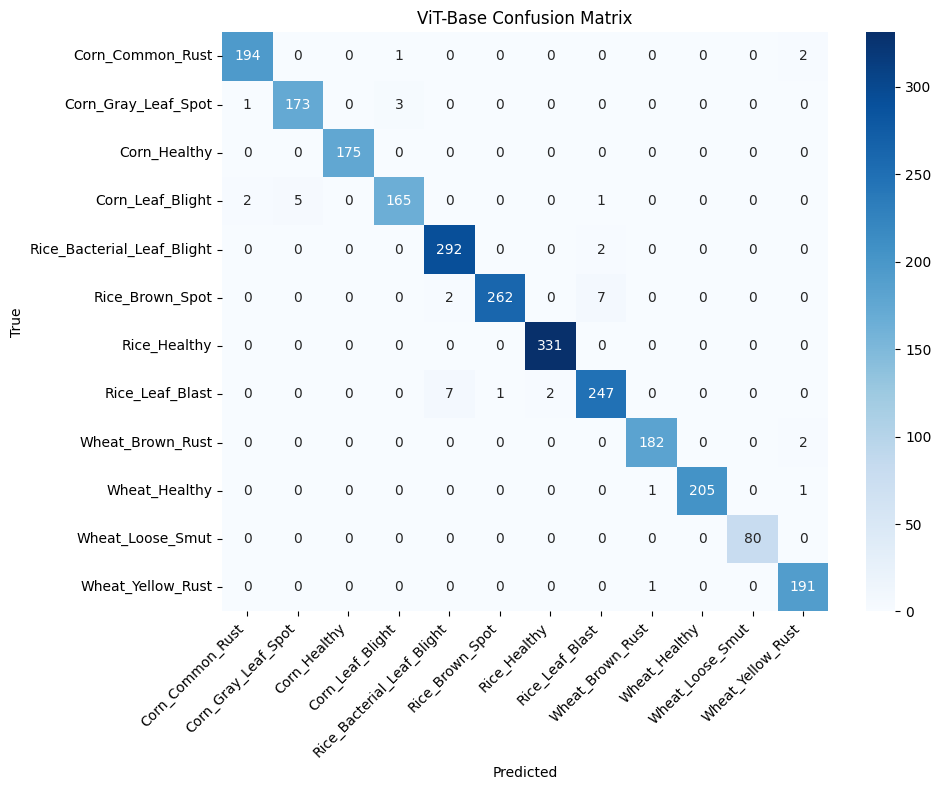

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open(f'{backup_folder}/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('ViT-Base Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{backup_folder}/confusion_matrix.png')
plt.show()

## Step 14 — Model size, parameters, and inference time

In [14]:
import time

tf.get_logger().setLevel('ERROR')

model_path = f'{backup_folder}/best_vit_model.keras'
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)

dummy_input = np.random.uniform(0, 255, (1, 224, 224, 3)).astype(np.float32)
_ = model(dummy_input, training=False)  # warm-up

times = []
for _ in range(100):
    start = time.time()
    _ = model(dummy_input, training=False)
    times.append((time.time() - start) * 1000)

avg_inference_time = np.mean(times)

print("=" * 60)
print("SUMMARY FOR COMPARISON TABLE (ViT-Base)")
print("=" * 60)
print(f"Model size (MB):       {model_size_mb:.2f}")
print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {int(trainable_params):,}")
print(f"Inference time (ms):   {avg_inference_time:.2f}")

SUMMARY FOR COMPARISON TABLE (ViT-Base)
Model size (MB):       984.77
Total parameters:      85,998,604
Trainable parameters:  85,998,604
Inference time (ms):   224.92


## Step 15 — Single image prediction with confidence

Saving Wheat_Yellow_Rust134.jpg to Wheat_Yellow_Rust134.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


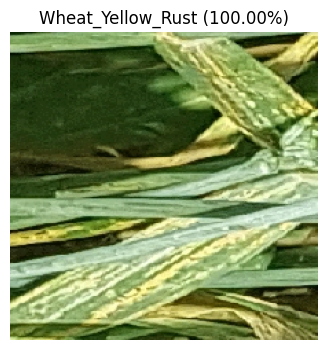

Predicted class: Wheat_Yellow_Rust
Confidence: 100.00%

Top 3 predictions:
  Wheat_Yellow_Rust: 100.00%
  Wheat_Healthy: 0.00%
  Wheat_Brown_Rust: 0.00%


In [15]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img).astype(np.float32)
img_array = np.expand_dims(img_array, axis=0)

preds = model.predict(img_array)
pred_index = np.argmax(preds[0])
pred_class = class_names[pred_index]
confidence = preds[0][pred_index] * 100

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"{pred_class} ({confidence:.2f}%)")
plt.show()

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

top3_idx = np.argsort(preds[0])[::-1][:3]
print("\nTop 3 predictions:")
for idx in top3_idx:
    print(f"  {class_names[idx]}: {preds[0][idx]*100:.2f}%")